<a href="https://colab.research.google.com/github/ishikadubey1105/HACK-O-WEEK-SEM-V/blob/main/week13_week_14_ensembles_bias_variance_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 14 — Ensemble Methods, Bias-Variance, Overfitting & Regularization

**Topics:**
1. Ensemble methods — Bagging, Boosting (XGBoost, LightGBM)
2. Bias–variance trade-off
3. Overfitting & underfitting — causes, identification, prevention
4. Regularization (L1/L2) and generalization

Dataset: `student_habits_performance.csv` (same one used all semester).
Target: `exam_score >= 60` -> `Pass`/`Fail` (binary classification), so every
model in this notebook can be compared on the same accuracy/F1 scale.

> **Colab note:** Upload `student_habits_performance.csv` first, and run
> `!pip install xgboost lightgbm -q` if they aren't already installed in your
> Colab runtime. A synthetic fallback dataset keeps the notebook runnable
> without the CSV.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load & Prepare Data

In [2]:
DATA_PATH = "student_habits_performance.csv"

def generate_synthetic_dataset(n=1000):
    study_hours = np.clip(np.random.normal(4.0, 1.8, n), 0, 12)
    sleep_hours = np.clip(np.random.normal(6.8, 1.2, n), 3, 10)
    attendance = np.clip(np.random.normal(85, 10, n), 40, 100)
    social_media = np.clip(np.random.normal(2.5, 1.3, n), 0, 8)
    netflix = np.clip(np.random.normal(1.2, 1.0, n), 0, 6)
    mental_health = np.random.randint(1, 11, n)
    exercise_freq = np.random.poisson(2.5, n).clip(0, 7)
    exam_score = np.clip(
        study_hours * 6.5 + sleep_hours * 2.0 + attendance * 0.25
        - social_media * 3.0 - netflix * 2.0 + mental_health * 1.2
        + np.random.normal(0, 8, n), 0, 100
    ).round(1)
    return pd.DataFrame({
        "study_hours_per_day": study_hours.round(1), "sleep_hours": sleep_hours.round(1),
        "attendance_percentage": attendance.round(1), "social_media_hours": social_media.round(1),
        "netflix_hours": netflix.round(1), "mental_health_rating": mental_health,
        "exercise_frequency": exercise_freq, "exam_score": exam_score,
    })

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape}")
else:
    print("CSV not found — using synthetic fallback.")
    df = generate_synthetic_dataset(1000)

df = df.drop_duplicates()
if "parental_education_level" in df.columns:
    df["parental_education_level"] = df["parental_education_level"].fillna("Unknown")

features = [c for c in [
    "study_hours_per_day", "sleep_hours", "attendance_percentage",
    "social_media_hours", "netflix_hours", "mental_health_rating", "exercise_frequency",
] if c in df.columns]

df["pass_fail"] = (df["exam_score"] >= 60).astype(int)
X = df[features].fillna(df[features].median())
y = df["pass_fail"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Features used:", features)
print("Train/Test sizes:", len(X_train), "/", len(X_test))


Loaded real dataset: (1000, 16)
Features used: ['study_hours_per_day', 'sleep_hours', 'attendance_percentage', 'social_media_hours', 'netflix_hours', 'mental_health_rating', 'exercise_frequency']
Train/Test sizes: 800 / 200


## 2. Bias–Variance Trade-off (intuition first)

- **High bias (underfitting)**: the model is too simple to capture the
  pattern — it's wrong in a consistent way on both train and test data.
- **High variance (overfitting)**: the model is too flexible — it memorizes
  training data (including its noise) and fails to generalize to new data.
- The trade-off: as model complexity increases, bias tends to go **down**
  but variance tends to go **up**. The sweet spot minimizes total error.

We'll make this concrete with a single decision tree at increasing `max_depth`.


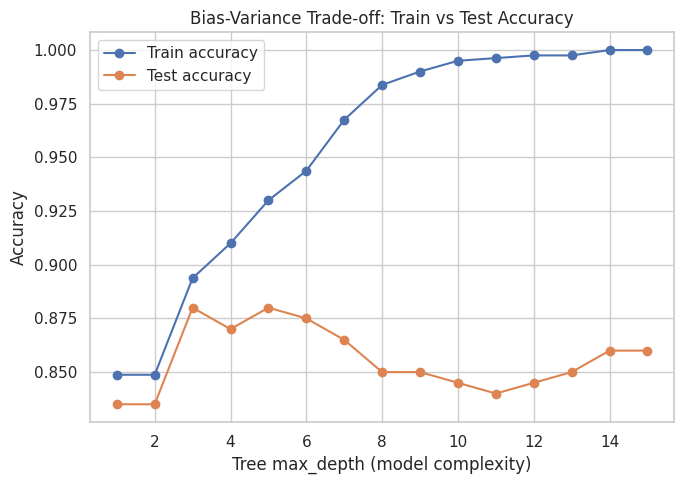

Depth with smallest train-test gap: 1
Depth with highest test accuracy  : 3


In [3]:
depths = range(1, 16)
train_acc, test_acc = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train_s, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train_s)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test_s)))

fig, ax = plt.subplots()
ax.plot(list(depths), train_acc, marker="o", label="Train accuracy")
ax.plot(list(depths), test_acc, marker="o", label="Test accuracy")
ax.set_xlabel("Tree max_depth (model complexity)")
ax.set_ylabel("Accuracy")
ax.set_title("Bias-Variance Trade-off: Train vs Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

gap = np.array(train_acc) - np.array(test_acc)
print("Depth with smallest train-test gap:", list(depths)[int(np.argmin(np.abs(gap)))])
print("Depth with highest test accuracy  :", list(depths)[int(np.argmax(test_acc))])


**Reading the plot:** at low depth, both train and test accuracy are low
(underfitting / high bias). As depth increases, train accuracy keeps
climbing toward ~1.0 while test accuracy plateaus or drops — the growing
gap between the two lines *is* overfitting / high variance in action.


## 3. Overfitting & Underfitting — Learning Curves

A learning curve (accuracy vs training-set size) is a second way to diagnose
the same issue:
- Both curves low and close together -> **underfitting** (more data won't help much; the model itself is too weak).
- Big gap between train (high) and validation (lower) -> **overfitting** (more data, or regularization, usually helps).


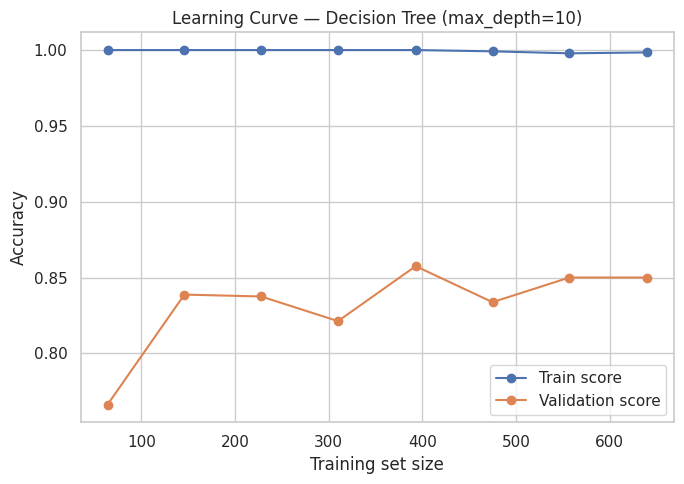

In [4]:
train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    X_train_s, y_train, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy", random_state=RANDOM_STATE,
)

fig, ax = plt.subplots()
ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train score")
ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation score")
ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — Decision Tree (max_depth=10)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Regularization (L1/L2) — Controlling Overfitting

Logistic Regression lets us compare **L1 (Lasso-style)** and **L2 (Ridge-style)**
penalties directly: both shrink coefficients to reduce variance, but L1 can
push some coefficients to exactly zero (automatic feature selection), while
L2 shrinks all of them smoothly.

`C` is the inverse of regularization strength: **smaller `C` = stronger
regularization**.


In [5]:
C_values = [0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    for penalty in ["l1", "l2"]:
        model = LogisticRegression(C=C, penalty=penalty, solver="liblinear", random_state=RANDOM_STATE)
        model.fit(X_train_s, y_train)
        train_a = accuracy_score(y_train, model.predict(X_train_s))
        test_a = accuracy_score(y_test, model.predict(X_test_s))
        n_zero_coefs = int(np.sum(np.abs(model.coef_) < 1e-6))
        results.append({"C": C, "penalty": penalty, "train_acc": train_a,
                         "test_acc": test_a, "zero_coefs": n_zero_coefs})

reg_results = pd.DataFrame(results)
reg_results


,C,penalty,train_acc,test_acc,zero_coefs
0,0.01,l1,0.85250,0.845,6
1,0.01,l2,0.92500,0.910,0
2,0.10,l1,0.93125,0.915,0
3,0.10,l2,0.92750,0.915,0
4,1.00,l1,0.92875,0.920,0
5,1.00,l2,0.93125,0.920,0
6,10.00,l1,0.93000,0.915,0
7,10.00,l2,0.93000,0.915,0
8,100.00,l1,0.93000,0.915,0
9,100.00,l2,0.93000,0.915,0


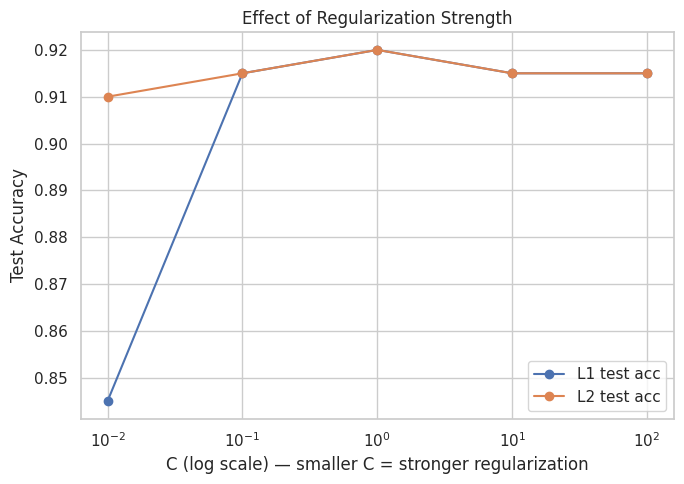

L1 zeroes out coefficients as C shrinks (feature selection):
        C  zero_coefs
0    0.01           6
2    0.10           0
4    1.00           0
6   10.00           0
8  100.00           0


In [6]:
fig, ax = plt.subplots()
for penalty, group in reg_results.groupby("penalty"):
    ax.plot(group["C"], group["test_acc"], marker="o", label=f"{penalty.upper()} test acc")
ax.set_xscale("log")
ax.set_xlabel("C (log scale) — smaller C = stronger regularization")
ax.set_ylabel("Test Accuracy")
ax.set_title("Effect of Regularization Strength")
ax.legend()
plt.tight_layout()
plt.show()

print("L1 zeroes out coefficients as C shrinks (feature selection):")
print(reg_results[reg_results.penalty == "l1"][["C", "zero_coefs"]])


## 5. Ensemble Methods

**Bagging** (Bootstrap Aggregating): train many models in *parallel* on
random bootstrap samples of the data, then average/vote their predictions.
Reduces **variance** — great for high-variance models like deep decision trees.

**Boosting**: train models *sequentially*, each one focusing on the errors
the previous ones made. Reduces **bias** as well as variance, often reaching
higher accuracy, but can overfit if run too long / too aggressively.


### 5.1 Bagging

In [7]:
single_tree = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
single_tree.fit(X_train_s, y_train)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    n_estimators=100, random_state=RANDOM_STATE,
)
bagging.fit(X_train_s, y_train)

random_forest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
random_forest.fit(X_train_s, y_train)

for name, model in [("Single Decision Tree (unpruned)", single_tree),
                     ("Bagging (100 trees)", bagging),
                     ("Random Forest (200 trees)", random_forest)]:
    train_a = accuracy_score(y_train, model.predict(X_train_s))
    test_a = accuracy_score(y_test, model.predict(X_test_s))
    print(f"{name:32s} -> train acc: {train_a:.3f}  test acc: {test_a:.3f}  gap: {train_a - test_a:.3f}")


Single Decision Tree (unpruned)  -> train acc: 1.000  test acc: 0.860  gap: 0.140
Bagging (100 trees)              -> train acc: 1.000  test acc: 0.920  gap: 0.080
Random Forest (200 trees)        -> train acc: 1.000  test acc: 0.905  gap: 0.095


**Takeaway:** a single unpruned tree usually has a large train/test gap
(it memorizes training data = overfitting). Bagging and Random Forest reduce
that gap by averaging over many trees trained on different bootstrap
samples — this is variance reduction in action.


### 5.2 Boosting — AdaBoost, Gradient Boosting, XGBoost, LightGBM

In [8]:
boosting_models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=150, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                              eval_metric="logloss", random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                                random_state=RANDOM_STATE, verbose=-1),
}

boosting_rows = []
for name, model in boosting_models.items():
    model.fit(X_train_s, y_train)
    train_a = accuracy_score(y_train, model.predict(X_train_s))
    test_a = accuracy_score(y_test, model.predict(X_test_s))
    test_f1 = f1_score(y_test, model.predict(X_test_s))
    boosting_rows.append({"model": name, "train_acc": round(train_a, 3),
                           "test_acc": round(test_a, 3), "test_f1": round(test_f1, 3)})

boosting_results = pd.DataFrame(boosting_rows).sort_values("test_acc", ascending=False)
boosting_results


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,train_acc,test_acc,test_f1
0,AdaBoost,0.930,0.910,0.938
1,Gradient Boosting,0.999,0.910,0.938
2,XGBoost,1.000,0.900,0.931
3,LightGBM,1.000,0.895,0.927


/tmp/ipykernel_793/3111527005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=boosting_results, x="model", y="test_acc", palette="viridis", ax=ax)


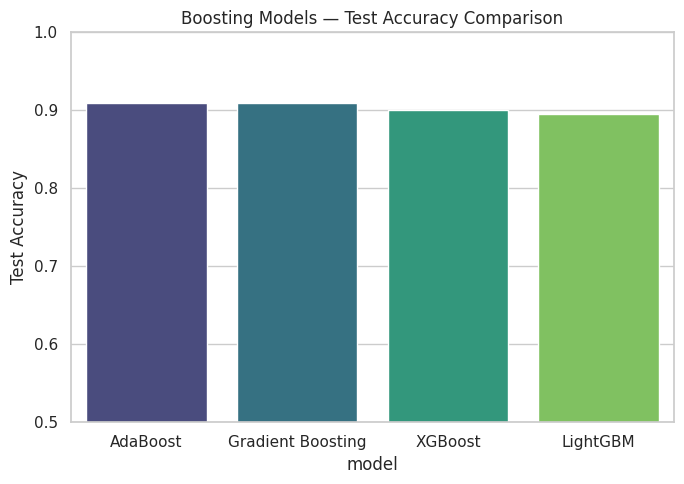

In [9]:
fig, ax = plt.subplots()
sns.barplot(data=boosting_results, x="model", y="test_acc", palette="viridis", ax=ax)
ax.set_ylim(0.5, 1.0)
ax.set_title("Boosting Models — Test Accuracy Comparison")
ax.set_ylabel("Test Accuracy")
plt.tight_layout()
plt.show()


## 6. Boosting Can Overfit Too — `n_estimators` vs Train/Test Accuracy

Boosting reduces bias by continually fitting residual errors, but too many
rounds starts fitting noise in the training data — regularization
(`learning_rate`, `max_depth`, early stopping) keeps this in check.


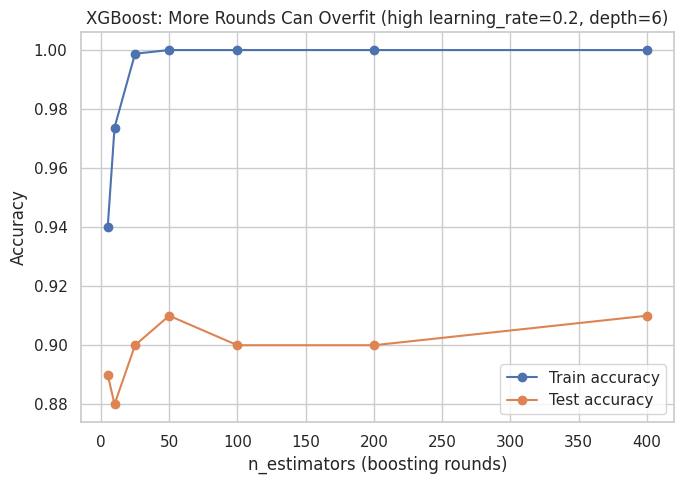

In [10]:
n_estimators_range = [5, 10, 25, 50, 100, 200, 400]
xgb_train_acc, xgb_test_acc = [], []

for n in n_estimators_range:
    model = XGBClassifier(n_estimators=n, max_depth=6, learning_rate=0.2,
                           eval_metric="logloss", random_state=RANDOM_STATE)
    model.fit(X_train_s, y_train)
    xgb_train_acc.append(accuracy_score(y_train, model.predict(X_train_s)))
    xgb_test_acc.append(accuracy_score(y_test, model.predict(X_test_s)))

fig, ax = plt.subplots()
ax.plot(n_estimators_range, xgb_train_acc, marker="o", label="Train accuracy")
ax.plot(n_estimators_range, xgb_test_acc, marker="o", label="Test accuracy")
ax.set_xlabel("n_estimators (boosting rounds)")
ax.set_ylabel("Accuracy")
ax.set_title("XGBoost: More Rounds Can Overfit (high learning_rate=0.2, depth=6)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. All Models Side by Side

In [11]:
baseline_rows = pd.DataFrame([
    {"model": "Logistic Regression (L2, C=1)",
     "test_acc": accuracy_score(y_test, LogisticRegression(C=1, penalty="l2", solver="liblinear", random_state=RANDOM_STATE).fit(X_train_s, y_train).predict(X_test_s))},
    {"model": "Single Decision Tree", "test_acc": accuracy_score(y_test, single_tree.predict(X_test_s))},
    {"model": "Bagging", "test_acc": accuracy_score(y_test, bagging.predict(X_test_s))},
    {"model": "Random Forest", "test_acc": accuracy_score(y_test, random_forest.predict(X_test_s))},
])

all_results = pd.concat([baseline_rows, boosting_results[["model", "test_acc"]]], ignore_index=True)
all_results = all_results.sort_values("test_acc", ascending=False).reset_index(drop=True)
all_results


,model,test_acc
0,"Logistic Regression (L2, C=1)",0.920
1,Bagging,0.920
2,Gradient Boosting,0.910
3,AdaBoost,0.910
4,Random Forest,0.905
5,XGBoost,0.900
6,LightGBM,0.895
7,Single Decision Tree,0.860


/tmp/ipykernel_793/3975495033.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_results, x="test_acc", y="model", palette="mako", ax=ax)


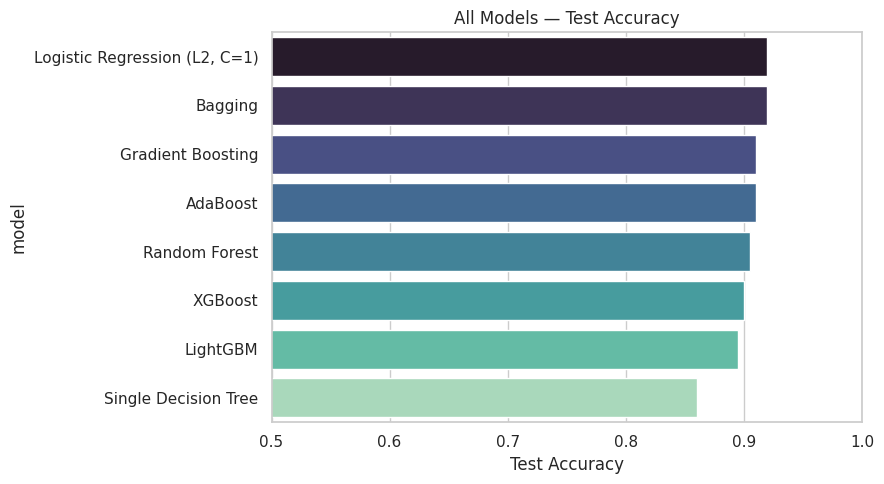

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=all_results, x="test_acc", y="model", palette="mako", ax=ax)
ax.set_xlim(0.5, 1.0)
ax.set_title("All Models — Test Accuracy")
ax.set_xlabel("Test Accuracy")
plt.tight_layout()
plt.show()


## 8. Summary

In [13]:
best_model_row = all_results.iloc[0]
print("Week 14 summary")
print("-" * 45)
print(f"Best model           : {best_model_row['model']} (test acc {best_model_row['test_acc']:.3f})")
print(f"Single tree test acc : {accuracy_score(y_test, single_tree.predict(X_test_s)):.3f} "
      f"(train acc {accuracy_score(y_train, single_tree.predict(X_train_s)):.3f} -> overfits)")
print(f"Bagging reduced the train/test gap vs. a single unpruned tree.")
print(f"Boosting models (XGBoost/LightGBM) pushed accuracy further by correcting errors sequentially.")
print(f"Regularization (L1/L2) and ensemble averaging both fight overfitting — the key theme this week.")


Week 14 summary
---------------------------------------------
Best model           : Logistic Regression (L2, C=1) (test acc 0.920)
Single tree test acc : 0.860 (train acc 1.000 -> overfits)
Bagging reduced the train/test gap vs. a single unpruned tree.
Boosting models (XGBoost/LightGBM) pushed accuracy further by correcting errors sequentially.
Regularization (L1/L2) and ensemble averaging both fight overfitting — the key theme this week.
